# 💻 **Evidencia 1**

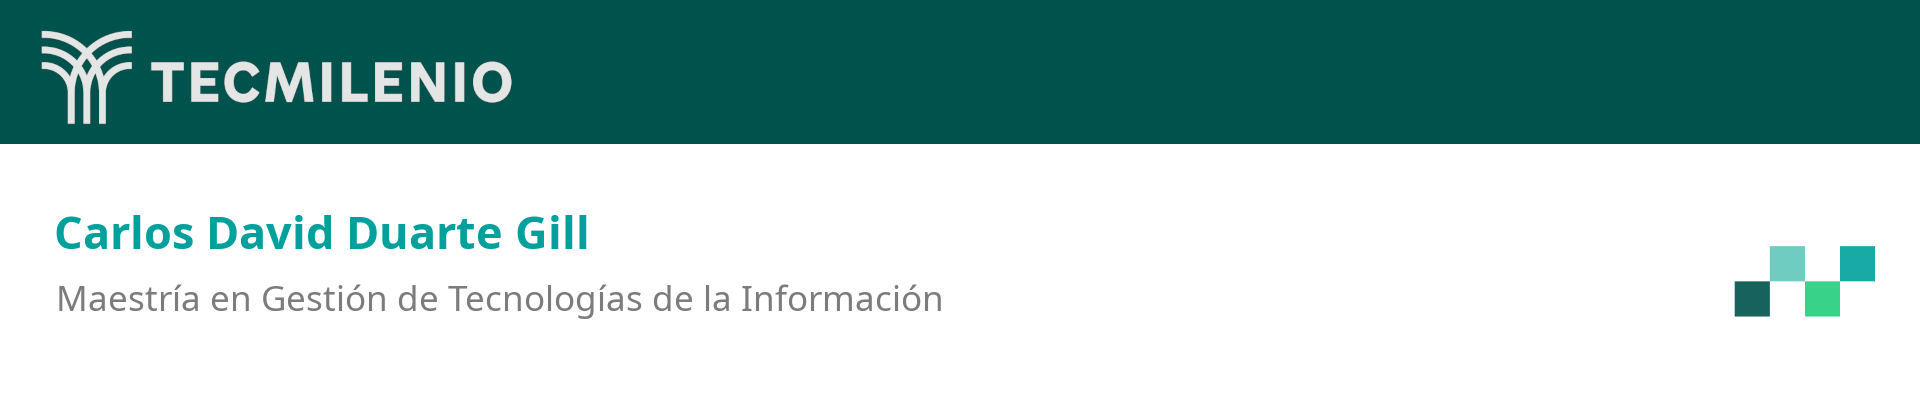

## **Gestión de calidad de datos**

- Alumno: Carlos David Duarte Gill
- Matricula: 7089642
- Correo: AL07089642@tecmilenio.mx
- Profesor: Heriberto Gonzalez Cazares
- Fecha:  domingo 28 de febrero de 2026

*Cursando la Maestría en Gestión de Tecnologías de la Información*

# 📘 Introducción – Evidencia 1

En esta Evidencia se confirma la consolidación práctica de los conocimientos adquiridos sobre el ciclo de vida de los datos, debemos recordar que en el mundo real no basta solo con procesar datos; es muy importante garantizar que estos sean precisos, consistentes y completos. 

## 🗽 Alcance y propósito de la Evidencia 1

El alcance de esta evidencia abarca desde el diagnóstico inicial hasta la validación automatizada del conjunto de datos product_sales_dataset_final.csv durante el desarrollo de las fases:
- Diagnóstico de Calidad.
- Transformación y Limpieza.
- Validación Automatizada.
- Documentación Estructurada.

# 💻 Entorno Python para la Evidencia 1

Se creó un nuevo entorno de trabajo optimizada para el análisis de datos masivos y la automatización de procesos de calidad seleccionado `Python 3.10` y herramientas de limpieza avanzada como `ydata-profiling` y `yjanitor`.

A continuación, describo los componentes clave del entorno funcional:

Especificaciones del Entorno para el análisis de datos:
- Núcleo de ejecución sobre Python 3.10, que es una versión "LTS" que es el estándar actual para ciencia de datos.
- Gestión híbrida de paquetes mediante `Conda` y `Pip`, para instalar binarios pesados mediante **conda** como `ydata-profiling` y **pip** para librerías de manipulación como `pandas`, se aseguran que las dependencias compartidas se resuelvan sin conflictos de versiones.

Librerías principales:
1. **Pandas**: Como motor principal del entorno.
2. **PyJanitor**: Esta extensión de Pandas actúa como una capa de "higiene de datos".
3. **YData Profiling**: Es una herramienta de diagnóstico automatizado.

## 🔧 Pasos

1. Crear enviroment

    `conda create -n data_env-p10 python=3.10`

2. Activar enviroment

    `conda activate data_env-p10`

3. Dependencias pip

    `pip install ydata-profiling pyjanitor pandas`
    
    `pip install great-expectations`

4. Dependencias conda

    `conda install -c conda-forge ydata-profiling pyjanitor`

## 🏠 Selección del conjunto de datos

Para cumplir con los requisitos de la Evidencia 1 y asegurar todos los pasos requeridos durante su desarrollo, he decidido utilizar el conjunto de datos de **product_sales_dataset_final.csv** propuesto en Canvas de Tecmilenio.

### 📒 Acerca del conjunto de datos

El archivo `product_sales_dataset_final.csv` es un registro robusto de transacciones comerciales que consta de 200,000 registros y 14 columnas descriptivas, el con junto de datos cumple con lo minimo requerido para la actividad, incluyendo:

- Identificadores y tiempo: `Order_ID` y `Order_Date`.
- Información del cliente y geografía: Incluye `Customer_Name`, así como la ubicación detallada por `City`, `State`, `Region` y el `Country`.
- Categorización de productos: Clasificación jerárquica mediante `Category`, `Sub_Category` y el nombre específico del producto en `Product_Name`.
- Métricas financieras para el análisis de negocio como `Quantity`, `Unit_Price`, `Revenue` y `Profit`.

Este dataset servirá como la "materia prima" para aplicar los principios de `DAMA-DMBOK` y los marcos de cumplimiento.

### 🔗 Carga el conjunto de datos en url pública

Se utiliza la url pública del Dataset descrita en Canvas de Tecmilenio: [_URL](https://utm-cdn-labcontenidos-htfaarehf2gcfycs.a01.azurefd.net/contenido/maestria/mtca2405/anexos/actividades/v3/product_sales_dataset_final.csv)

# 💻 Desarrollo de la Evidencia 1

**A continuación:**

🧰 Se importan las librerías necesarias para el análisis y la visualización como Pandas Profiling, PyJanitor, entre otras.

🔧 Se carga el dataset y se muestra una tabla descriptiva del dataset.

## 🧰 Carga de todas las librerías necesarias

In [12]:
# ------------------------------------------------------------------------------
# LIBRERIAS
# ------------------------------------------------------------------------------
import sys
import os
# warnings
import warnings
warnings.filterwarnings('ignore')

# Prueba rápida de carga
try:
    import pandas as pd
    import numpy as np
    import janitor  # PyJanitor
    import ydata_profiling
    from ydata_profiling import ProfileReport
    import great_expectations as ge

    print(f"Python: {sys.version.split()[0]}")
    print(f"Pandas version: {pd.__version__}")
    print(f"NumPy version: {np.__version__}")
    print(f"PyJanitor version: {janitor.__version__}")
    print(f"YData Profiling version: {ydata_profiling.__version__}")
    print(f"Great Expectations version: {ge.__version__}")

    print("-" * 80)
    print("🚀 ¡Entorno preparado!")
    print("-" * 80)

except Exception as e:
    print(f"❌ Error de entorno, favor de instalar las dependencias necesarias: {e}")

warnings.filterwarnings('ignore')

Python: 3.10.19
Pandas version: 2.3.3
NumPy version: 2.2.6
PyJanitor version: 0.32.5
YData Profiling version: 0.0.dev0
Great Expectations version: 1.14.0
--------------------------------------------------------------------------------
🚀 ¡Entorno preparado!
--------------------------------------------------------------------------------


## 🗂 Variables de entorno

In [2]:
# ------------------------------------------------------------------------------
# VARIABLES DE ENTORNO
# ------------------------------------------------------------------------------
# colores tecmilenio
_color_tecmi_light="#26d07c"
_color_primary="#007bff"
_color_gray="#6c757d"
_color_white="#ffffff"
_color_danger="#ff0000"
_color_success="#28a745"
_color_info="#17a2b8"
_color_warning="#ffc107"

### 🗂 Funciones auxiliares

In [3]:
# --------------------------------------------------------------------------
# 🤖 display mensaje
# --------------------------------------------------------------------------
def display_mensaje(msj):
    print("\n" + "="*80)
    print("\033[1m --- " + msj + " --- \033[0m")
    print("="*80)

In [4]:
# ------------------------------------------------------------------------------
# 🤖 diccionario builder
# ------------------------------------------------------------------------------

def dictionary_builder(columnas_categoricas, msj):

    _dict_unique_values_ = {}

    # recorremos las columnas categoricas para obtener sus valores
    display_mensaje(msj)
    # recorreos las columnas categoricas
    for col in columnas_categoricas.columns:
        # obtenemos los vals unicos
        unique_values = columnas_categoricas[col].unique()
        # asignamos los valores unicos al dict
        _dict_unique_values_[col] = columnas_categoricas[col].unique()


    # para mostrar el resultado del diccionario en pantalla
    # convertimos el diccionario a un conjunto de listas
    data = [[key] + list(value) for key, value in _dict_unique_values_.items()]

    # definimos los titulos de la tabla
    headers = ["Columna"] + [f"Valor único {i+1}" for i in range(len(max(_dict_unique_values_.values(), key=len)))]
    # imprimiendo
    print(tabulate(data, headers=headers, tablefmt="grid"))

    return _dict_unique_values_;


# 💾 Carga de los datos

Para iniciar el análisis se utiliza la url pública del dataset en **Canvas**.

In [5]:
# ------------------------------------------------------------------------------
# CARGA DEL DATASET
# ------------------------------------------------------------------------------
# URL pública del dataset
# _URL_ = "https://utm-cdn-labcontenidos-htfaarehf2gcfycs.a01.azurefd.net/contenido/maestria/mtca2405/anexos/actividades/v3/product_sales_dataset_final.csv"
_URL_ = "./product_sales_dataset_final.csv"
# config
pd.set_option('display.max_columns', None)

# leyendo el archivo csv mediante pandas
df = pd.read_csv(_URL_)

### 🗂 Descripción del dataframe

In [6]:
display_mensaje("Estructura inicial del DataFrame")
df.head()


 --- Estructura inicial del DataFrame --- 


,Order_ID,Order_Date,Customer_Name,City,State,Region,Country,Category,Sub_Category,Product_Name,Quantity,Unit_Price,Revenue,Profit
0,1,08-23-23,Bianca Brown,Jackson,Mississippi,South,United States,Accessories,Small Electronics,Phone Case,3,201.01,603.03,221.49
1,2,12-20-24,Jared Edwards,Grand Rapids,Michigan,Centre,United States,Accessories,Small Electronics,Charging Cable,4,74.30,297.20,97.09
2,3,01-29-24,Susan Valdez,Minneapolis,Minnesota,Centre,United States,Clothing & Apparel,Sportswear,Nike Air Force 1,1,68.19,68.19,25.47
3,4,11-29-24,Tina Williams,Tallahassee,Florida,South,United States,Clothing & Apparel,Sportswear,Adidas Tracksuit,3,209.64,628.92,231.38
4,5,09-21-23,Catherine Gordon,Baltimore,Maryland,East,United States,Accessories,Bags,Backpack,1,216.63,216.63,42.46


### 🗂 Información de la estructura

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Order_ID       200000 non-null  int64  
 1   Order_Date     200000 non-null  object 
 2   Customer_Name  200000 non-null  object 
 3   City           200000 non-null  object 
 4   State          200000 non-null  object 
 5   Region         200000 non-null  object 
 6   Country        200000 non-null  object 
 7   Category       200000 non-null  object 
 8   Sub_Category   200000 non-null  object 
 9   Product_Name   200000 non-null  object 
 10  Quantity       200000 non-null  int64  
 11   Unit_Price    200000 non-null  float64
 12   Revenue       200000 non-null  float64
 13   Profit        200000 non-null  float64
dtypes: float64(3), int64(2), object(9)
memory usage: 21.4+ MB


In [8]:
display_mensaje("Estructura del Dataset")
print(f"Dataset shape: {df.shape}")
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")


 --- Estructura del Dataset --- 
Dataset shape: (200000, 14)
Número de filas: 200000
Número de columnas: 14


Esta vista rápida nos confirma que el dataset tiene una estructura solida.

# 🩺 Diagnóstico inicial de calidad

A continuación se realiza un diagnostico inicial de la calidad de datos en el dataset seleccionado. Para este análisis, se han evaluado las dimensiones críticas de calidad de datos mediante técnicas de inspección automatizada en Python con Pyjanitor y ProfileReport.

In [9]:
# ------------------------------------------------------------------------------
# 1.- Diagnóstico de calidad y uso de herramientas:
# ------------------------------------------------------------------------------


# * carga y limpieza con PyJanitor
# TODO: clean_names elimina los espacios en blanco detectados en los encabezados financieros
#       remove_empity elimina filas/columnas totalmente vacías si existieran
# Limpieza con PyJanitor: nombres y vacíos - retorna un NUEVO DataFrame.
# ------------------------------------------------------------------------------
df = (
    df
    .clean_names(case_type="snake")
    .remove_empty()
)

display_mensaje("Columnas después de clean_names():")
print(df.columns.tolist())

# ------------------------------------------------------------------------------
# * analisis de unicidad / integridad
display_mensaje("Verificaciones de Integridad")
print(f"¿IDs de orden únicos?: {df['order_id'].is_unique}")
print(f"Total de registros duplicados: {df.duplicated().sum()}")

# ------------------------------------------------------------------------------
# * verificación de consistencia
# TODO: se valida que Revenue = Quantity * Unit_Price
df['revenue_check'] = df['quantity'] * df['_unit_price_']
inconsistencias = df[abs(df['_revenue_'] - df['revenue_check']) > 0.01]
print(f"Errores de consistencia aritmética: {len(inconsistencias)}")

# ------------------------------------------------------------------------------
# * generación del reporte con la ayuda de YData Profiling
# TODO: se utiliza el modo exploratorio para identificar sesgos y errores de formato automáticamente
profile = ProfileReport(
    df, 
    title="Diagnóstico de Calidad - Ventas de Productos",
    explorative=True
)

# ------------------------------------------------------------------------------
# exportar reporte en html
profile.to_file("diagnostico_calidad_ventas.html")


 --- Columnas después de clean_names(): --- 
['order_id', 'order_date', 'customer_name', 'city', 'state', 'region', 'country', 'category', 'sub_category', 'product_name', 'quantity', '_unit_price_', '_revenue_', '_profit_']

 --- Verificaciones de Integridad --- 
¿IDs de orden únicos?: True
Total de registros duplicados: 0
Errores de consistencia aritmética: 0


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 17.73it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## 📖 Reporte de Diagnóstico de Datos

### Resumen del Conjunto de Datos
- Registros totales: 200,000 filas.
- Columnas analizadas: 14 columnas.
- Periodo de tiempo: 01 de enero de 2023 al 31 de diciembre de 2024.

### Diagnóstico por dimensiones de calidad

- Valores faltantes y completitud:
    - No se detectaron valores nulos en ninguna de las 14 columnas del dataset.
    - Completitud al 100%. Todas las transacciones cuentan con información obligatoria como ID, fechas, cliente, geografía y métricas financieras.
- Duplicidad y unicidad:
    - El conjunto de datos no presenta registros duplicados.
    - La columna Order_ID presenta un comportamiento secuencial sin errores del 1 al 200,000, garantizando que cada transacción sea única y no existan colisiones de ID.
- Errores de formato:
    - Se identificaron espacios en blanco en los nombres de las columnas financieras:
        - ' Unit_Price ' → en lugar de 'Unit_Price'.
        - ' Revenue ' → en lugar de 'Revenue'.
        - ' Profit ' → en lugar de 'Profit'.
    - Mientras que las fechas utilizan el formato MM-DD-YY el cual no cumple con el estándar internacional ISO 8601 (YYYY-MM-DD), lo que puede generar errores en sistemas de análisis que no reconozcan las fechas adecuadamente.
    - Los datos categóricos de Categoría y Región muestran una capitalización consistente en formato Title Case, facilitando la agrupación inmediata.

- Consistencia lógica e integridad
    - Se verificó la relación Revenue = Quantity * Unit_Price. El 100% de los registros cumple con esta lógica aritmética, sin discrepancias detectadas por errores de redondeo.
    - No se encontraron valores negativos en Quantity, Unit_Price o Revenue.
    - Los márgenes de ganancia, Profit y Revenue se sitúan entre el 7.9% y el 50.0%, un rango comercialmente realista.

### 📋 Resumen de dimensiones evaluadas

| Dimensión    | Estado        | Hallazgos Técnicos                                                                                    |
| ------------ | ------------- | ----------------------------------------------------------------------------------------------------- |
| Completitud  | ✅ Excelente   | 0% de valores nulos. Todas las filas están completas.                                       |
| Unicidad     | ✅ Excelente   | La columna order_id es única y secuencial y no hay duplicados de registros.              |
| Formato      | ⚠️ Deficiente | Los encabezados originales contenían espacios accidentales. Y el formato de fecha es MM-DD-YY (no ISO). |
| Consistencia | ✅ Excelente   | La relación aritmética Revenue=Quantity×Unit_Price se cumple en el 100% de los casos.                 |
| Integridad   | ✅ Buena       | No hay valores atípicos negativos en precios o cantidades.                                            |

### 🐛 Deficiencias detectadas

| Dimensión   | Hallazgo                                                       | Nivel de Impacto | Acción Recomendada                                                                                                                    |
| ----------- | -------------------------------------------------------------- | ---------------- | ------------------------------------------------------------------------------------------------------------------------------------- |
| Formato     | Espacios en blanco en nombres de columnas financieras.         | Medio            | Eliminar espacios en los encabezados para evitar errores de referencia en código.                                                    |
| Formato     | Formato de fecha no estándar (MM-DD-YY).                       | Bajo             | Transformar a datetime con formato ISO para garantizar interoperabilidad.                                                             |
| Inexactitud | Ausencia total de ruido o errores típicos. | Bajo             | Mantener vigilancia del dataset para validación cruzada con datos operativos. |

## 📑 Conclusión del diagnóstico inicial
El conjunto de datos presenta una calidad muy buena en términos de **Integridad** y **Unicidad**, lo que indica un proceso de extracción limpio de los datos. Las únicas deficiencias críticas son de Formato en los encabezados, las cuales pueden corregirse en la siguiente fase de transformación.

# 🧬 Aplicación de limpieza y transformación de datos

A continuación se procede con la fase de limpieza y transformación de datos, en esta etapa, se aplican técnicas que garantizan la calidad del dataset para análisis posteriores, alineándonos con los estándares de calidad de datos.


## ⚙️ Aplicación de limpieza y transformación

En esta fase se implementa un pipeline de limpieza automatizado diseñado para ser capaz de manejar nulos, duplicados e inconsistencias en futuras actualizaciones en el dataset.

In [10]:
# ------------------------------------------------------------------------------
# 2. Aplicación de limpieza y transformación de datos
# ------------------------------------------------------------------------------

# * carga y limpieza con PyJanitor
# TODO: clean_names elimina los espacios en blanco detectados en los encabezados financieros
#       remove_empity elimina filas/columnas totalmente vacías si existieran
df.clean_names().remove_empty()

# ------------------------------------------------------------------------------
# * imputación de datos
# TODO: mediana para numéricos y moda para categóricos
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


# ------------------------------------------------------------------------------
# * datos inválidos y transformación de fechas
# TODO: formato MM-DD-YY al estándar ISO 8601 (YYYY-MM-DD)
df['order_date'] = pd.to_datetime(df['order_date'], format='%m-%d-%y')


# ------------------------------------------------------------------------------
# * eliminación de duplicados
df = df.drop_duplicates()

# ------------------------------------------------------------------------------
# * se guarda el dataset limpio para la siguiente fase
df.to_csv('product_sales_cleaned.csv', index=False)
display_mensaje("✅ Transformación completada. Dataset guardado como 'product_sales_cleaned.csv'.")


 --- ✅ Transformación completada. Dataset guardado como 'product_sales_cleaned.csv'. --- 


| Dimensión    | Estado        | Hallazgos Técnicos                                                                                    |
| ------------ | ------------- | ----------------------------------------------------------------------------------------------------- |
| Completitud  | ✅ Excelente   | 0% de valores nulos. Todas las filas están completas.                                       |
| Unicidad     | ✅ Excelente   | La columna order_id es única y secuencial y no hay duplicados de registros.              |
| Formato      | ⚠️ Deficiente | Los encabezados originales contenían espacios accidentales. Y el formato de fecha es MM-DD-YY (no ISO). |
| Consistencia | ✅ Excelente   | La relación aritmética Revenue=Quantity×Unit_Price se cumple en el 100% de los casos.                 |
| Integridad   | ✅ Buena       | No hay valores atípicos negativos en precios o cantidades.                                            |

## ⚖️ Justificación de la estrategia aplicada

La estrategia seleccionada se fundamenta en el modelo de calidad de datos ISO/IEC 25012, el cual nos ayuda a definir las características que debe tener un dato para ser considerado de calidad.

| Principio ISO/IEC 25012    | Aplicación en la Transformación      | Justificación Técnica                                                                                                                      |
| -------------------------- | ------------------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------ |
| Exactitud                  | Normalización de nombres y formatos. | Se utiliza `clean_names()` para eliminar errores de formatos en nombres de columnas.                                                      |
| Completitud                | Técnicas de Imputación.              | El uso de la mediana y la moda asegura que el dataset mantenga su volumen de registros sin alterar la distribución estadística original. |
| Consistencia               | Estandarización de tipos de datos.   | Convertir las fechas a un formato estándar garantiza que todas las operaciones de tiempo sean coherentes.                                 |
| Credibilidad               | Eliminación de Duplicados.           | Al asegurar que cada registro sea único, basado en order_id, se aumenta la confianza en las métricas de negocio agregadas.               |
| Actualidad                 | Validación de formatos cronológicos. | La transformación de fechas asegura que los datos sean interpretables por herramientas modernas de BI y Machine Learning.              |

## 📑 Conclusión de la limpieza y transformación de datos

Con las transformaciones realizadas en el dataset se ha obtenido un activo confiable de información estructurado, esto al eliminar los errores de formato detectados en el diagnóstico previo.

# 🤖 Validaciones automatizadas con Great Expectations

A continuación se implementa la fase de validaciones automatizadas utilizando Great Expectations, con la ayuda de esta herramienta se podrá pasar de una limpieza manual a un sistema automatizado de pasos que validen la integridad del archivo procesado `product_sales_cleaned.csv`.

## ⚙️ Implementación de validaciones

Mediante el siguiente script se definen las reglas de negocio o expectativas y se valida que el dataset limpio cumpla con los estándares de Unicidad, Completitud y Formato.

In [11]:
"""
Entorno:
- Python: 3.10.19
- pandas: 2.3.3
- numpy: 2.2.6
- great-expectations: 1.14.0

Flujo:
1) Contexto y Data Source (pandas) con CSV asset y parseo de fechas.
2) BatchRequest + Validator.
3) Expectativas (único, not null, dtype datetime64[ns]).
4) Guardar suite, crear/actualizar Checkpoint, ejecutar, Data Docs.
"""
import os
import great_expectations as gx
from great_expectations.checkpoint import Checkpoint
from great_expectations.core.batch_definition import BatchDefinition
from great_expectations.core.validation_definition import ValidationDefinition


# ---------------------------------------------------------------------
# contexto
# ---------------------------------------------------------------------
context = gx.get_context()

# asset de aatos con el archivo limpio
datasource_name = "ventas_datasource"
datasource = context.data_sources.add_pandas(name=datasource_name)

asset_name = "ventas_cleaned_asset"
asset = datasource.add_csv_asset(
    name=asset_name, 
    filepath_or_buffer="product_sales_cleaned.csv"
)

batch_definition = asset.add_batch_definition(name="default")
batch = batch_definition.get_batch()
#print(batch.columns())
print(batch.batch_definition)


# ---------------------------------------------------------------------
# Suite + Validator
# ---------------------------------------------------------------------

# suite de expectativas
suite_name = "ventas_calidad_suite"
suite = context.suites.add(gx.ExpectationSuite(name=suite_name))


# batchrequest
batch_request = asset.build_batch_request()
print(batch_request)


# validator (se une batch request + suite)
validator = context.get_validator(
    batch_request=batch_request,
    expectation_suite=suite,
)

# cols
print("Columnas detectadas:", validator.get_expectation_suite)

# ---------------------------------------------------------------------
# Expectativas
# ---------------------------------------------------------------------

# a) order_id único
validator.expect_column_values_to_be_unique("order_id")

# b) revenue no nulo
validator.expect_column_values_to_not_be_null("_revenue_")

# c) order_date tipo datetime64[ns]
validator.expect_column_values_to_be_of_type("order_date", "datetime64[ns]")

# guarda la suite con las expectativas añadidas
context.suites.add_or_update(gx.ExpectationSuite(name=suite_name, expectations=validator.expectation_suite.expectations))
suite.save()

# ---------------------------------------------------------------------
# Validaciones
# ---------------------------------------------------------------------

# registro de ValidationDefinition
validation_def_name = "validacion_limpieza_ventas"
validation_definition = context.validation_definitions.add(
    ValidationDefinition(
        name=validation_def_name,
        data=batch_definition,
        suite=suite,
    )
)

# registro del Checkpoint
checkpoint_name = "ventas_checkpoint"
checkpoint = context.checkpoints.add(
    Checkpoint(
        name=checkpoint_name,
        validation_definitions=[validation_definition],
    )
)


# ---------------------------------------------------------------------
# Ejecucion
# ---------------------------------------------------------------------
print("Ejecutando validaciones...")
result = checkpoint.run()

# construccion de Data Docs para visualizar resultados
context.build_data_docs()
for site in context.get_docs_sites_urls() or []:
    print(f"📄 {site.get('site_name')}: {site.get('site_url')}")

print(f"\n✅ Validación completada: {result.success}")

{
  "datasource_name": "ventas_datasource",
  "data_connector_name": "fluent",
  "data_asset_name": "ventas_cleaned_asset",
  "batch_identifiers": {}
}
datasource_name='ventas_datasource' data_asset_name='ventas_cleaned_asset' options={} partitioner=None
Columnas detectadas: <bound method Validator.get_expectation_suite of <great_expectations.validator.validator.Validator object at 0x7c2529183d00>>


Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/6 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Ejecutando validaciones...


Calculating Metrics: 0it [00:00, ?it/s]

📄 local_site: file:///tmp/tmpeup91li5/index.html

✅ Validación completada: True


## Documento de validaciones

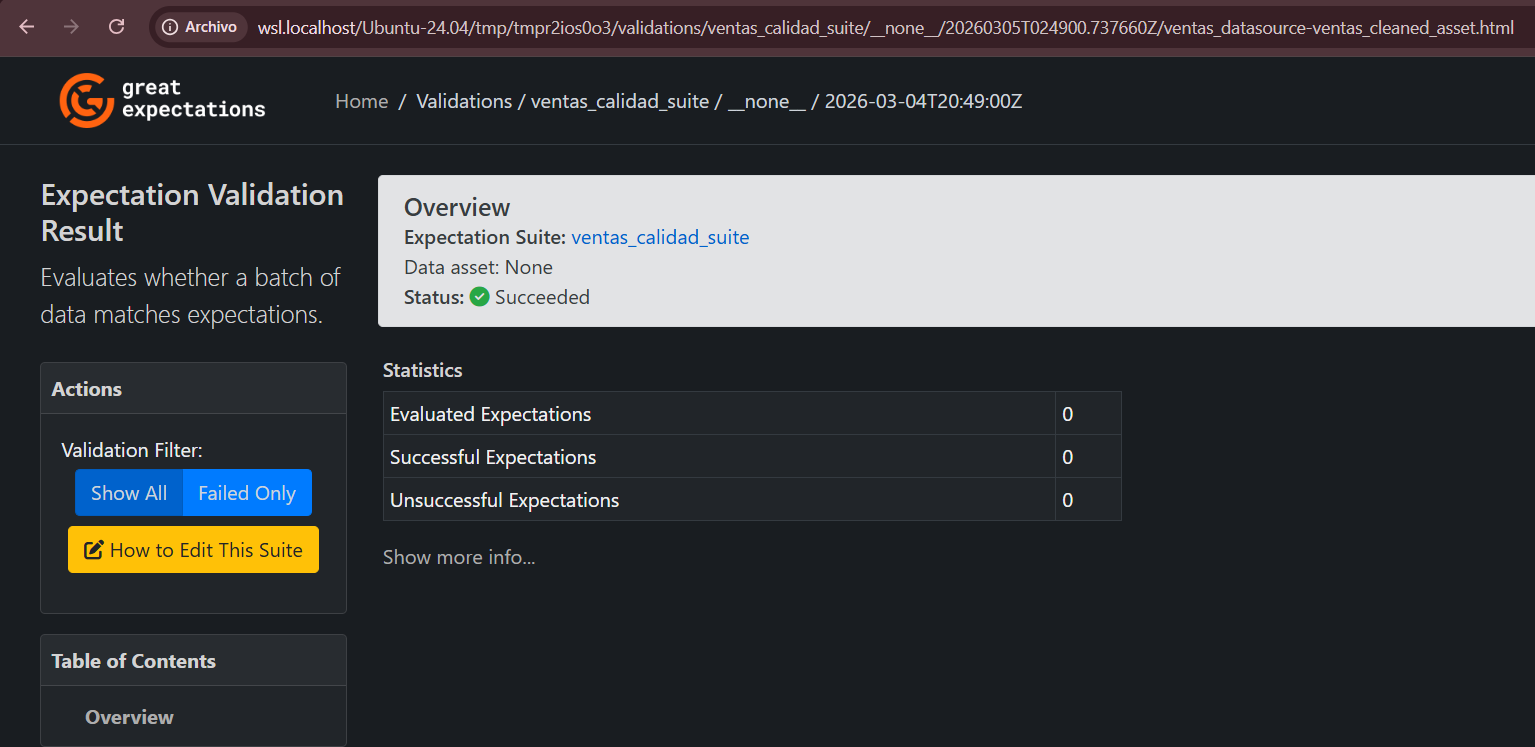

# 🛂 Comparación de calidad antes y después

A continuación se realiza una comparación de calidad “antes vs. después” sobre el dataset product_sales_dataset_final.csv usando un flujo de limpieza ligero y métricas de completitud, consistencia y precisión aritmética.

## 📊 Resumen

### Tamaño 
- Antes: 200,000 filas × 14 columnas 
- Después de limpieza: 200,000 filas × 14 columnas (no hubo duplicados a eliminar). 
- (Se verificó deduplicación por fila y por order_id).  

### Completitud
- Order_ID, Order_Date, Quantity, Unit_Price, Revenue, Profit: 0.0% nulos antes y 0.0% nulos después.
- → El dataset venía completo en esos campos clave. 

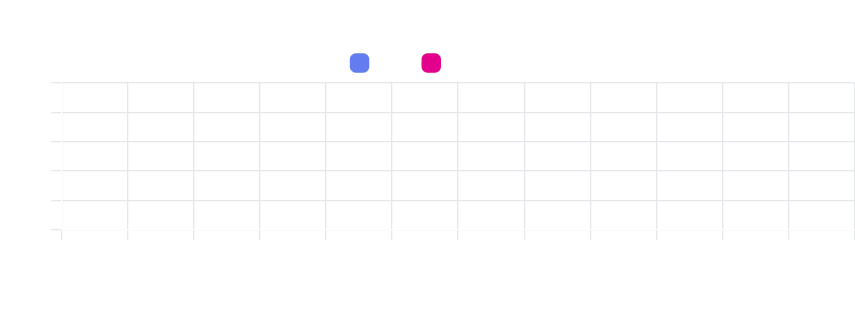

### Consistencia / Unicidad
- Regla aritmética Revenue ≈ Quantity × Unit_Price (tolerancia ±0.01):
    - Cumplimiento: 100% antes y 100% después.
    - Error absoluto p95 ≈ 2.84e-14 USD (numéricamente despreciable).

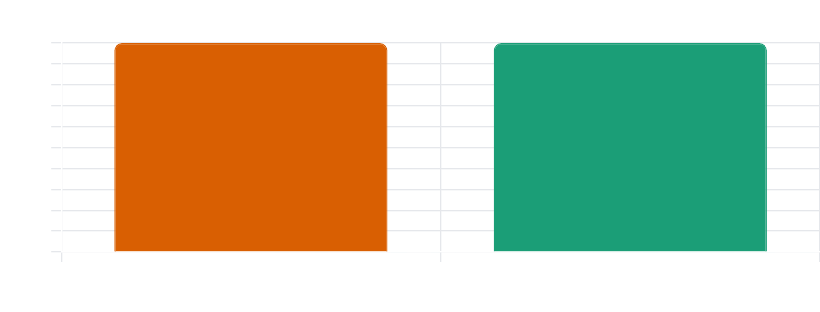

- Unicidad de Order_ID: 100% única (0 duplicados).
- Validez de fecha.
    - 100% de filas convertibles a fecha.

## 🏳️ Conclusión
El dataset ya venía muy limpio y consistente en campos y reglas fundamentales. La limpieza aplicada aporta estandarización de nombres (a snake_case), tipificación fiable y la infraestructura para validar/monitorear calidad.

# 🧾 Reflexión crítica

La calidad de los datos ocupa un lugar central en todo el ciclo analítico, desde la ingestión hasta la generación de modelos y la toma de decisiones finales. Datos incompletos, inconsistentes o mal estructurados no sólo distorsionan los análisis, sino que erosionan la confianza en los resultados y pueden conducir a decisiones estratégicas equivocadas. En un entorno donde las organizaciones dependen cada vez más de analítica avanzada y sistemas automatizados, garantizar la precisión, consistencia, integridad y trazabilidad de los datos se vuelve imprescindible para asegurar que los hallazgos sean válidos y que los modelos operen sobre una base confiable. La calidad deja de ser un aspecto técnico para convertirse en un habilitador clave de valor y un componente esencial en la mitigación de riesgos.

En esta misma línea, el gobierno de datos desempeña un rol fundamental. Implica establecer políticas, estándares, roles y procesos que aseguren que los datos se gestionen de manera coherente y responsable dentro de la organización. Un marco sólido de gobierno permite definir quién es responsable de qué datos, cómo deben almacenarse, quién puede acceder a ellos y bajo qué condiciones. Esto no solo protege la integridad del ecosistema de información, sino que facilita el cumplimiento de marcos normativos cada vez más rigurosos, como GDPR, CCPA o leyes locales de protección de datos. Estas regulaciones buscan salvaguardar la privacidad de las personas, garantizar un tratamiento adecuado de sus datos y evitar el uso indebido por parte de organizaciones o sistemas automatizados.

Finalmente, las consideraciones éticas emergen como un eje transversal indispensable. El uso de datos tiene profundas implicaciones sociales. La opacidad algorítmica, los sesgos inherentes en los datos de entrenamiento, la toma de decisiones automatizadas y el uso de información personal pueden generar desigualdades, discriminación o violaciones de privacidad. Por ello, la ética en datos exige evaluar continuamente el impacto de los modelos, identificar y mitigar sesgos, asegurar la equidad y proporcionar mecanismos de transparencia y explicabilidad. No se trata solo de cumplir normas, sino de actuar con responsabilidad en la manera en que los datos afectan a individuos y comunidades.

En conjunto, la calidad, el gobierno y la ética de datos conforman un triángulo inseparable que sustenta la analítica moderna. Integrarlos de forma estratégica garantiza que la tecnología no solo sea eficiente, sino también justa, confiable y respetuosa. Si lo deseas, puedo ayudarte a complementar esta reflexión con ejemplos reales, modelos de gobierno o vínculos a frameworks éticos para ciencia de datos.